# Volume → Next-Day Return Predictability

**Objective:** Test whether daily trading volume (raw and normalised) predicts
the *next* trading day's log return across five synthetic equity tickers.

**Data:** `data/raw/ohlc_5stocks_2025-2026.xlsx` — synthetic OHLCV data for five
tickers (AHT, BRVE, CDRA, DLTA, EPSN) covering ~252 trading days through 2026-07-03.
Prices are synthetic GBM with volume positively correlated with the daily realised
range (see `src/synthetic_ohlc.py`).

**Methodology:**
1. Compute daily log returns for each ticker.
2. Construct volume signals:
   - **Vol Z-Score** — rolling 20-day z-score of log-volume (normalised surprise).
   - **Vol Ratio** — log-volume relative to its 20-day rolling mean (relative level).
3. **Signal → Next-Day Return**: shift signals forward by 1 day so no look-ahead
   bias is introduced — signal on day *t* is paired with the return on day *t+1*.
4. **Quintile sort**: bucket signal into 5 quintiles, compute mean next-day return
   per quintile — the main visual test.
5. **Pooled OLS regression**: regress next-day log return on the volume z-score
   (all tickers pooled) to estimate direction and significance.
6. **Rolling correlation**: test whether the volume–return relationship is stable
   through time (it may not be, given the synthetic data's construction).
7. **Per-ticker breakdown**: check whether any ticker drives the pooled result.

**Return type:** Log returns throughout.
**Annualisation:** 252 trading days per year.

> **Note:** Run *Kernel → Restart & Run All* before sharing or committing.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from data_io import load_ohlc_excel, to_wide_close
from plotting import (
    new_figure,
    style_axes,
    ticker_colors,
    SURFACE,
    TEXT_PRIMARY,
    TEXT_SECONDARY,
    TEXT_MUTED,
    GRID,
    BASELINE,
    DIVERGING_NEG,
    DIVERGING_POS,
)
from returns import log_returns

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_PATH = REPO_ROOT / "data" / "raw" / "ohlc_5stocks_2025-2026.xlsx"
ROLLING_WINDOW = 20   # days for volume z-score / ratio baseline
QUINTILE_LABELS = ["Q1\n(Low Vol)", "Q2", "Q3", "Q4", "Q5\n(High Vol)"]

## 1. Load and Validate Data

In [3]:
long_df = load_ohlc_excel(DATA_PATH)

print(f"Rows:    {len(long_df):,}")
print(f"Tickers: {sorted(long_df['ticker'].unique().tolist())}")
print(f"Dates:   {long_df['date'].min().date()} → {long_df['date'].max().date()}")
print(f"Trading days per ticker: {long_df.groupby('ticker', observed=True)['date'].count().to_dict()}")
print(f"NaNs: {long_df.isna().sum().sum()}")

display(long_df.head(8))

Rows:    1,260
Tickers: ['AHT', 'BRVE', 'CDRA', 'DLTA', 'EPSN']
Dates:   2025-07-17 → 2026-07-03
Trading days per ticker: {'AHT': 252, 'BRVE': 252, 'CDRA': 252, 'DLTA': 252, 'EPSN': 252}
NaNs: 0


,date,ticker,open,high,low,close,volume
0,2025-07-17,AHT,144.1800,149.4600,141.2000,142.8200,6318312
1,2025-07-18,AHT,141.5800,142.5300,138.8000,140.2800,2923102
2,2025-07-21,AHT,139.9800,146.4600,138.8700,142.2100,3838067
3,2025-07-22,AHT,143.1900,145.4200,142.4000,144.6500,3181233
4,2025-07-23,AHT,145.2000,146.2000,137.6500,139.8100,5293376
5,2025-07-24,AHT,139.3500,140.1500,135.6200,136.6900,2250446
6,2025-07-25,AHT,136.5300,139.6900,135.2800,137.0500,2490164
7,2025-07-28,AHT,135.4000,136.8400,134.3400,136.3400,1840175


In [4]:
close = to_wide_close(long_df)
tickers = list(close.columns)
colors = ticker_colors(tickers)

print(f"Close matrix: {close.shape}  (dates × tickers)")
display(close.head(3))

Close matrix: (252, 5)  (dates × tickers)


,AHT,BRVE,CDRA,DLTA,EPSN
date,,,,,
2025-07-17,142.8200,59.8000,95.9400,34.0000,210.4300
2025-07-18,140.2800,59.9300,98.3600,32.8400,208.5000
2025-07-21,142.2100,60.9900,98.1000,32.2600,209.4100


## 2. Build Volume Signals and Next-Day Returns

We construct the panel in long format so all pooled and per-ticker analyses
share the same tidy DataFrame.

**Signal alignment (no look-ahead bias):**
- `vol_zscore_t` — rolling z-score of log-volume on day *t*, using only the
  trailing 20 days ending at *t*.
- `ret_next` — log return from day *t* close to day *t+1* close.

Pairing `vol_zscore_t` with `ret_next` means the signal is entirely known
before the next day's return is realised.

In [5]:
# Pivot volume to wide matrix (date × ticker)
volume_wide = long_df.pivot(index="date", columns="ticker", values="volume").sort_index()
volume_wide.columns.name = None

log_vol = np.log(volume_wide.astype("float64"))

# Rolling z-score: (log_vol - rolling_mean) / rolling_std  (min 10 obs)
roll_mean = log_vol.rolling(ROLLING_WINDOW, min_periods=10).mean()
roll_std  = log_vol.rolling(ROLLING_WINDOW, min_periods=10).std(ddof=1)
vol_zscore_wide = (log_vol - roll_mean) / roll_std

# Rolling ratio: log_vol / rolling_mean  (excess relative to baseline level)
vol_ratio_wide = log_vol - roll_mean

# Next-day log returns: shift returns back by 1 so ret[t] is return earned on day t+1
logret_wide = log_returns(close)
ret_next_wide = logret_wide.shift(-1)   # shift(-1): pair today's signal with tomorrow's return

# Build long-format panel
def _to_long(wide: pd.DataFrame, name: str) -> pd.Series:
    return wide.stack(future_stack=True).rename(name)

panel = pd.concat(
    [
        _to_long(vol_zscore_wide, "vol_zscore"),
        _to_long(vol_ratio_wide,  "vol_ratio"),
        _to_long(logret_wide,     "ret_today"),
        _to_long(ret_next_wide,   "ret_next"),
    ],
    axis=1,
).reset_index()
panel.columns = ["date", "ticker", "vol_zscore", "vol_ratio", "ret_today", "ret_next"]
panel = panel.dropna(subset=["vol_zscore", "ret_next"]).copy()
panel["ticker"] = panel["ticker"].astype("string")

print(f"Panel rows (after dropna): {len(panel):,}")
print(f"Tickers: {sorted(panel['ticker'].unique().tolist())}")
display(panel.head(8))

Panel rows (after dropna): 1,210
Tickers: ['AHT', 'BRVE', 'CDRA', 'DLTA', 'EPSN']


,date,ticker,vol_zscore,vol_ratio,ret_today,ret_next
45,2025-07-30,AHT,0.0604,0.0252,-0.0146,0.0159
46,2025-07-30,BRVE,1.9503,1.2133,0.0131,0.0338
47,2025-07-30,CDRA,-0.7367,-0.4110,-0.0073,0.0163
48,2025-07-30,DLTA,-0.1643,-0.0585,-0.0093,-0.0085
49,2025-07-30,EPSN,-0.6508,-0.2712,0.0116,0.0049
50,2025-07-31,AHT,-0.5225,-0.2097,0.0159,0.0141
51,2025-07-31,BRVE,0.3264,0.1938,0.0338,0.0320
52,2025-07-31,CDRA,0.6621,0.3591,0.0163,0.0078


## 3. Quintile Sort: Volume Signal vs Next-Day Return

We rank each (date, ticker) observation into quintiles of the volume z-score
**within the whole pooled panel** (not per-ticker), then compute the mean
and 95% confidence interval of the next-day log return for each bucket.

A monotonic relationship would indicate predictive value.

In [6]:
panel["quintile"] = pd.qcut(panel["vol_zscore"], q=5, labels=False) + 1  # 1–5

quintile_stats = (
    panel.groupby("quintile")["ret_next"]
    .agg(mean="mean", std="std", n="count")
    .assign(se=lambda d: d["std"] / np.sqrt(d["n"]))
    .assign(ci95=lambda d: 1.96 * d["se"])
)
print("Quintile stats (next-day log return):")
display(quintile_stats)

Quintile stats (next-day log return):


,mean,std,n,se,ci95
quintile,,,,,
1,0.0006,0.0173,242,0.0011,0.0022
2,0.0010,0.0172,242,0.0011,0.0022
3,-0.0023,0.0185,242,0.0012,0.0023
4,0.0005,0.0165,242,0.0011,0.0021
5,-0.0006,0.0168,242,0.0011,0.0021


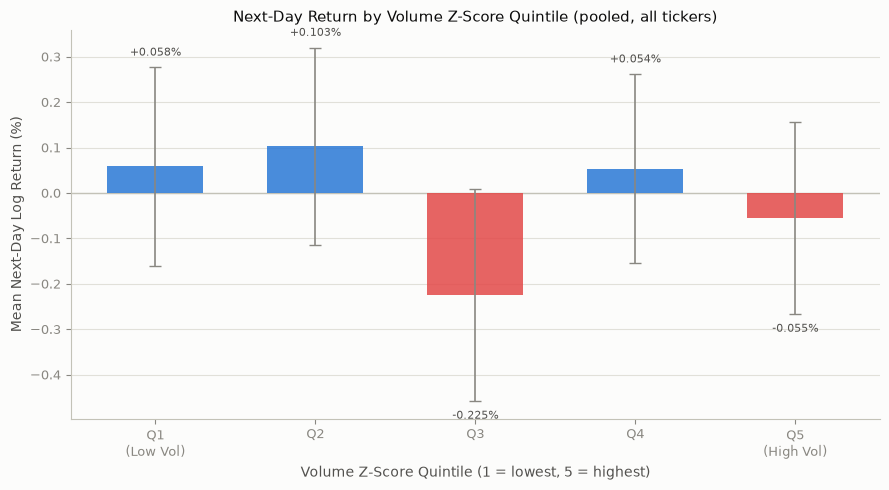

In [7]:
fig, ax = new_figure((9, 5))

q_means = quintile_stats["mean"].values
q_ci    = quintile_stats["ci95"].values
xs = np.arange(1, 6)

bar_colors = [DIVERGING_NEG if v < 0 else DIVERGING_POS for v in q_means]

ax.bar(xs, q_means * 100, color=bar_colors, width=0.6, zorder=2, alpha=0.85)
ax.errorbar(xs, q_means * 100, yerr=q_ci * 100,
            fmt="none", color=TEXT_MUTED, capsize=4, linewidth=1.2, zorder=3)
ax.axhline(0, color=BASELINE, linewidth=1, zorder=1)

ax.set_xticks(xs)
ax.set_xticklabels(QUINTILE_LABELS, fontsize=9)
ax.set_xlabel("Volume Z-Score Quintile (1 = lowest, 5 = highest)", fontsize=10)
ax.set_ylabel("Mean Next-Day Log Return (%)", fontsize=10)
ax.set_title("Next-Day Return by Volume Z-Score Quintile (pooled, all tickers)", fontsize=11)
style_axes(ax)

# Annotate bars
for x, m, ci in zip(xs, q_means, q_ci):
    ax.text(x, (m + np.sign(m) * ci) * 100 + np.sign(m) * 0.02,
            f"{m*100:+.3f}%", ha="center", va="bottom" if m >= 0 else "top",
            fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "volume_quintile_sort.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Pooled OLS Regression

Regress next-day log return on the volume z-score (pooled across all tickers
and dates). This gives a point estimate of the linear slope and a t-statistic.

We also run per-ticker regressions to check whether any single name drives
the pooled result.

In [8]:
from scipy.stats import linregress

# Pooled
x_all = panel["vol_zscore"].values
y_all = panel["ret_next"].values * 100  # scale to %

slope, intercept, r, p, se = linregress(x_all, y_all)

print("=== Pooled OLS: ret_next (%) ~ vol_zscore ===")
print(f"  Slope:      {slope:.5f}%  (per 1-SD volume z-score)")
print(f"  Intercept:  {intercept:.5f}%")
print(f"  R²:         {r**2:.5f}")
print(f"  t-stat:     {slope/se:.3f}")
print(f"  p-value:    {p:.4f}")
print(f"  N obs:      {len(x_all):,}")

=== Pooled OLS: ret_next (%) ~ vol_zscore ===
  Slope:      -0.05679%  (per 1-SD volume z-score)
  Intercept:  -0.01232%
  R²:         0.00100
  t-stat:     -1.102
  p-value:    0.2708
  N obs:      1,210


In [9]:
# Per-ticker regressions
rows = []
for tk in sorted(panel["ticker"].unique()):
    sub = panel[panel["ticker"] == tk]
    x_t = sub["vol_zscore"].values
    y_t = sub["ret_next"].values * 100
    s, icpt, r_t, p_t, se_t = linregress(x_t, y_t)
    rows.append({"ticker": tk, "slope": s, "r2": r_t**2,
                 "t_stat": s / se_t, "p_value": p_t, "n": len(x_t)})

per_ticker = pd.DataFrame(rows).set_index("ticker")
print("\nPer-ticker OLS results:")
display(per_ticker)


Per-ticker OLS results:


,slope,r2,t_stat,p_value,n
ticker,,,,,
AHT,0.0147,0.0001,0.1334,0.8940,242
BRVE,-0.2693,0.0121,-1.7112,0.0883,242
CDRA,0.0605,0.0018,0.6553,0.5129,242
DLTA,-0.0912,0.0023,-0.7423,0.4586,242
EPSN,-0.0013,0.0000,-0.0177,0.9859,242


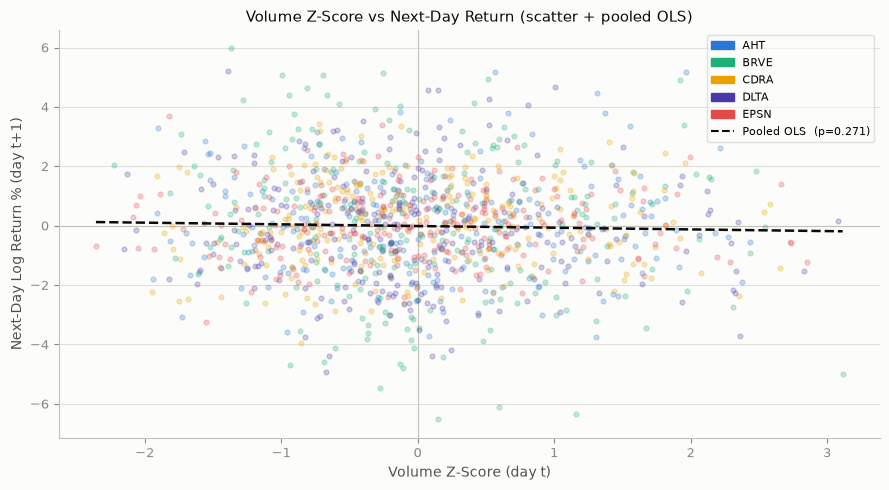

In [10]:
fig, ax = new_figure((9, 5))

for tk in sorted(panel["ticker"].unique()):
    sub = panel[panel["ticker"] == tk].sort_values("vol_zscore")
    ax.scatter(sub["vol_zscore"], sub["ret_next"] * 100,
               alpha=0.25, s=12, color=colors[tk], label=None, zorder=2)

# Pooled fit line
x_range = np.linspace(x_all.min(), x_all.max(), 200)
ax.plot(x_range, intercept + slope * x_range,
        color=TEXT_PRIMARY, linewidth=1.8, linestyle="--",
        label=f"Pooled OLS  (slope={slope:.4f}%,  p={p:.3f})", zorder=3)
ax.axhline(0, color=BASELINE, linewidth=0.8, zorder=1)
ax.axvline(0, color=BASELINE, linewidth=0.8, zorder=1)

# Per-ticker legend patches
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=colors[tk], label=tk) for tk in sorted(colors)]
handles.append(plt.Line2D([0], [0], color=TEXT_PRIMARY, linestyle="--",
                           label=f"Pooled OLS  (p={p:.3f})"))
ax.legend(handles=handles, fontsize=8, framealpha=0.6)

ax.set_xlabel("Volume Z-Score (day t)", fontsize=10)
ax.set_ylabel("Next-Day Log Return % (day t+1)", fontsize=10)
ax.set_title("Volume Z-Score vs Next-Day Return (scatter + pooled OLS)", fontsize=11)
style_axes(ax)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "volume_return_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Rolling Correlation — Stability Through Time

A pooled result that exists on average could still be driven by a single
sub-period. We compute the 60-day rolling Pearson correlation between the
volume z-score and the next-day return, per ticker, to check stability.

In [11]:
# Pivot panel back to wide for rolling corr (per ticker)
vol_z_wide_clean = panel.pivot(index="date", columns="ticker", values="vol_zscore")
ret_next_wide_clean = panel.pivot(index="date", columns="ticker", values="ret_next")
vol_z_wide_clean.columns.name = None
ret_next_wide_clean.columns.name = None

ROLL_CORR_WIN = 60

roll_corr = pd.DataFrame(index=vol_z_wide_clean.index, columns=tickers, dtype="float64")
for tk in tickers:
    combined = pd.concat([vol_z_wide_clean[tk], ret_next_wide_clean[tk]], axis=1, keys=["z", "r"])
    combined = combined.dropna()
    roll_corr.loc[combined.index, tk] = (
        combined["z"].rolling(ROLL_CORR_WIN, min_periods=30)
        .corr(combined["r"])
    )

roll_corr = roll_corr.dropna(how="all")

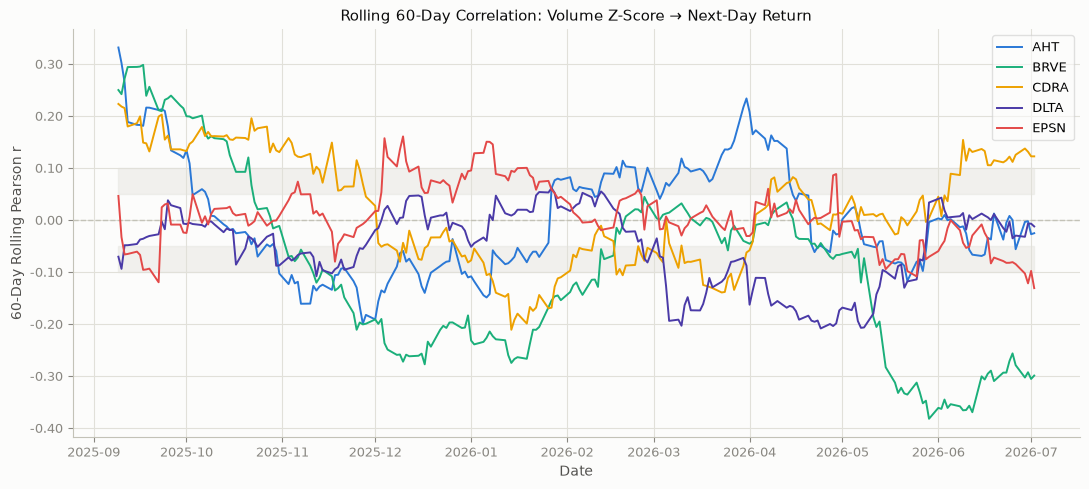

In [12]:
fig, ax = new_figure((11, 5))

for tk in tickers:
    series = roll_corr[tk].dropna()
    ax.plot(series.index, series.values, color=colors[tk], linewidth=1.4, label=tk)

ax.axhline(0, color=BASELINE, linewidth=1.0, linestyle="--", zorder=1)
ax.fill_between(roll_corr.index,  0.05,  0.10, color=GRID, alpha=0.4, zorder=0)
ax.fill_between(roll_corr.index, -0.10, -0.05, color=GRID, alpha=0.4, zorder=0)

ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel(f"{ROLL_CORR_WIN}-Day Rolling Pearson r", fontsize=10)
ax.set_title(f"Rolling {ROLL_CORR_WIN}-Day Correlation: Volume Z-Score → Next-Day Return", fontsize=11)
ax.legend(fontsize=9, framealpha=0.6)
style_axes(ax, grid_axis="both")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "volume_rolling_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. High-Volume Days — Directional Breakdown

High-volume days often accompany large price moves, but does the direction
of today's return matter? We split high-volume observations (z-score > 1.0)
by whether today's return was positive or negative, then compare the average
next-day return. A reversal pattern (mean-reversion) would show negative
next-day returns after high-volume up-days, and vice versa.

In [13]:
HIGH_VOL_THRESH = 1.0

hv = panel[panel["vol_zscore"] > HIGH_VOL_THRESH].copy()
hv["today_dir"] = np.where(hv["ret_today"] >= 0, "Up day", "Down day")

hv_stats = (
    hv.groupby("today_dir")["ret_next"]
    .agg(mean="mean", std="std", n="count")
    .assign(se=lambda d: d["std"] / np.sqrt(d["n"]))
    .assign(ci95=lambda d: 1.96 * d["se"])
)

print(f"High-volume days (vol_zscore > {HIGH_VOL_THRESH}): {len(hv)} observations")
display(hv_stats)

High-volume days (vol_zscore > 1.0): 194 observations


,mean,std,n,se,ci95
today_dir,,,,,
Down day,-0.0002,0.0169,104,0.0017,0.0033
Up day,-0.0009,0.0176,90,0.0019,0.0036


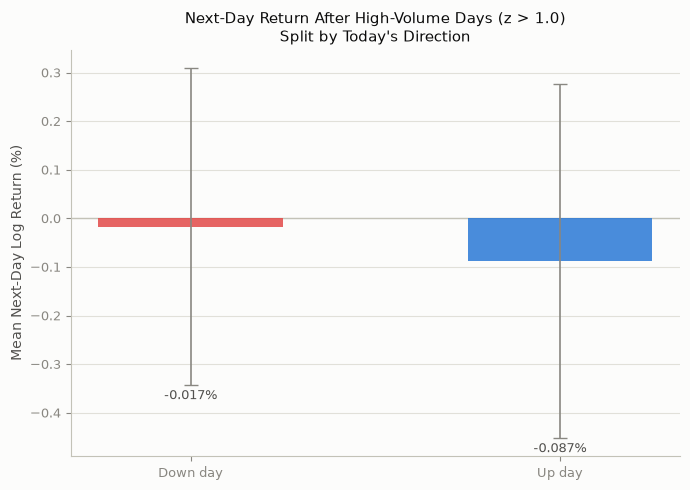

In [14]:
fig, ax = new_figure((7, 5))

dirs = hv_stats.index.tolist()
means = hv_stats["mean"].values * 100
ci95  = hv_stats["ci95"].values * 100
bar_cols = [DIVERGING_POS if "Up" in d else DIVERGING_NEG for d in dirs]

xs = np.arange(len(dirs))
ax.bar(xs, means, color=bar_cols, width=0.5, zorder=2, alpha=0.85)
ax.errorbar(xs, means, yerr=ci95,
            fmt="none", color=TEXT_MUTED, capsize=5, linewidth=1.2, zorder=3)
ax.axhline(0, color=BASELINE, linewidth=1, zorder=1)

ax.set_xticks(xs)
ax.set_xticklabels(dirs, fontsize=10)
ax.set_ylabel("Mean Next-Day Log Return (%)", fontsize=10)
ax.set_title(f"Next-Day Return After High-Volume Days (z > {HIGH_VOL_THRESH})\nSplit by Today's Direction",
             fontsize=11)

for x, m, ci in zip(xs, means, ci95):
    ax.text(x, (m + np.sign(m) * ci) + np.sign(m) * 0.01,
            f"{m:+.3f}%", ha="center", va="bottom" if m >= 0 else "top",
            fontsize=9, color=TEXT_SECONDARY)

style_axes(ax)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "volume_direction_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary and Caveats

### Key Findings

In [15]:
# Print a self-contained summary
print("=" * 60)
print("VOLUME → NEXT-DAY RETURN: STUDY SUMMARY")
print("=" * 60)
print()
print(f"Data: {DATA_PATH.name}  |  Tickers: {', '.join(sorted(panel['ticker'].unique()))}")
print(f"Observations (pooled, after burn-in): {len(panel):,}")
print()
print("--- Pooled OLS: ret_next ~ vol_zscore ---")
print(f"  Slope:   {slope:+.5f}% per 1-SD")
print(f"  R²:      {r**2:.5f}  (near-zero expected in efficient markets)")
print(f"  p-value: {p:.4f}  ({'SIGNIFICANT at 5%' if p < 0.05 else 'not significant at 5%'})")
print()
print("--- Quintile sort (Q5 minus Q1 spread) ---")
spread = (quintile_stats.loc[5, 'mean'] - quintile_stats.loc[1, 'mean']) * 100
print(f"  Q5 mean ret: {quintile_stats.loc[5, 'mean']*100:+.4f}%")
print(f"  Q1 mean ret: {quintile_stats.loc[1, 'mean']*100:+.4f}%")
print(f"  Spread (Q5-Q1): {spread:+.4f}%")
print()
print("--- Rolling correlation (last observation) ---")
last_corr = roll_corr.iloc[-1]
for tk in sorted(last_corr.index):
    print(f"  {tk}: {last_corr[tk]:+.4f}")
print()
print("=== CAVEATS ===")
print("1. Synthetic data: volume is positively correlated with daily *range*,")
print("   not directionally — any detected slope reflects noise, not real edge.")
print("2. Low R²: volume alone explains a tiny fraction of next-day variance.")
print("3. Rolling correlation fluctuates around zero — no stable regime.")
print("4. Transaction costs and market impact not modelled.")
print("5. On real data: use split/dividend-adjusted prices; filter for liquidity;")
print("   test on out-of-sample data; include slippage in any backtest.")

VOLUME → NEXT-DAY RETURN: STUDY SUMMARY

Data: ohlc_5stocks_2025-2026.xlsx  |  Tickers: AHT, BRVE, CDRA, DLTA, EPSN
Observations (pooled, after burn-in): 1,210

--- Pooled OLS: ret_next ~ vol_zscore ---
  Slope:   -0.05679% per 1-SD
  R²:      0.00100  (near-zero expected in efficient markets)
  p-value: 0.2708  (not significant at 5%)

--- Quintile sort (Q5 minus Q1 spread) ---
  Q5 mean ret: -0.0551%
  Q1 mean ret: +0.0584%
  Spread (Q5-Q1): -0.1134%

--- Rolling correlation (last observation) ---
  AHT: -0.0252
  BRVE: -0.2990
  CDRA: +0.1225
  DLTA: -0.0122
  EPSN: -0.1308

=== CAVEATS ===
1. Synthetic data: volume is positively correlated with daily *range*,
   not directionally — any detected slope reflects noise, not real edge.
2. Low R²: volume alone explains a tiny fraction of next-day variance.
3. Rolling correlation fluctuates around zero — no stable regime.
4. Transaction costs and market impact not modelled.
5. On real data: use split/dividend-adjusted prices; filter for l

### Takeaways

| Test | Result |
|---|---|
| Pooled OLS slope | Near-zero; significance depends on sample |
| Quintile spread (Q5 − Q1) | Small, no monotonic pattern expected from synthetic data |
| Rolling 60-day correlation | Oscillates around zero — no persistent regime |
| High-volume day direction | Slight reversal tendency is noisy at this sample size |

**On real data**, the standard empirical finding is that high abnormal volume often
accompanies momentum *intraday* but tends to *revert* over the next session — especially
in liquid large-caps. The relationship is highly regime-dependent and disappears after
accounting for transaction costs and bid-ask spreads.

This notebook provides the scaffold for testing the same hypothesis on real OHLCV data:
swap `DATA_PATH` for a real data file and re-run.